In [4]:
from astropy.table import Table
from common_functions import single_wavelet, plotter, reduce
import numpy as np
import matplotlib.colors as colors
import matplotlib.pylab as pylab
import os
import pathlib
from pyasassn.client import SkyPatrolClient
import matplotlib.pyplot as plt

In [5]:
help(single_wavelet)

Help on function single_wavelet in module common_functions:

single_wavelet(self, flux_list, min=False, scaled=False, tradeoff=2)
    Constructs a 2D wavelet-transform power spectrum of a single LightCurve Object.
    
    :param self: a LightCurve Object (re: https://github.com/asas-sn/skypatrol/blob/master/pyasassn/lightcurve.py / https://github.com/lightkurve/lightkurve/blob/main/src/lightkurve/lightcurve.py).
    :param flux: Array of flux values for the passing of an injected flux array in making a 2D wavelet transform.
    :param min: (Default: False) boolean, whether the transform should be min-masked (non-used method).
    :param scaled: (Default: False) boolean, whether the transform should be scaled 10x average power and capped at [0, 255] (non-used method). 
    :param tradeoff: int value to represent tradeoff between frequency/time resolution in the transformation (preset to 2 in Schochet et al.).
    
    
    :return: power_int, a 64x64 2D torch.Tensor object which holds 

# This notebook is meant to demonstrate how one would make a single object wavelet transform given a specific ASAS-SN ID

In [6]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()
params = {'figure.labelsize': 'x-large',
          'figure.titlesize': 'x-large',
          'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'axes.labelweight':'bold',
         'figure.labelweight':'bold'}
pylab.rcParams.update(params)

In [7]:
client = SkyPatrolClient()

Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.19 (22 MAY 2025)
Please upgrade your client if not up to date.

We are reprocessing a number of lightcurves in database.
Once finished we should have more complete and higher quality photometry.
Thank you for your patience,
K. Hart (22 MAY 2025)




In [16]:
def pipeline(objid, minimum=False, scaling=False):
    lcs = client.query_list([objid], download=True)
    for lc in lcs.itercurves():
        savedlc = lc
    savedlc_fin = reduce(savedlc)
    wavelet = single_wavelet(savedlc_fin, savedlc_fin.data.flux, minimum, scaling, 2)
    if (minimum==True):
        plotter(wavelet, True, "yes", "not")
    elif (scaling==True):
        plotter(wavelet, True, "not", "yes")
    else:
        plotter(wavelet, True)
    return(wavelet)

Pulled 1 of 1


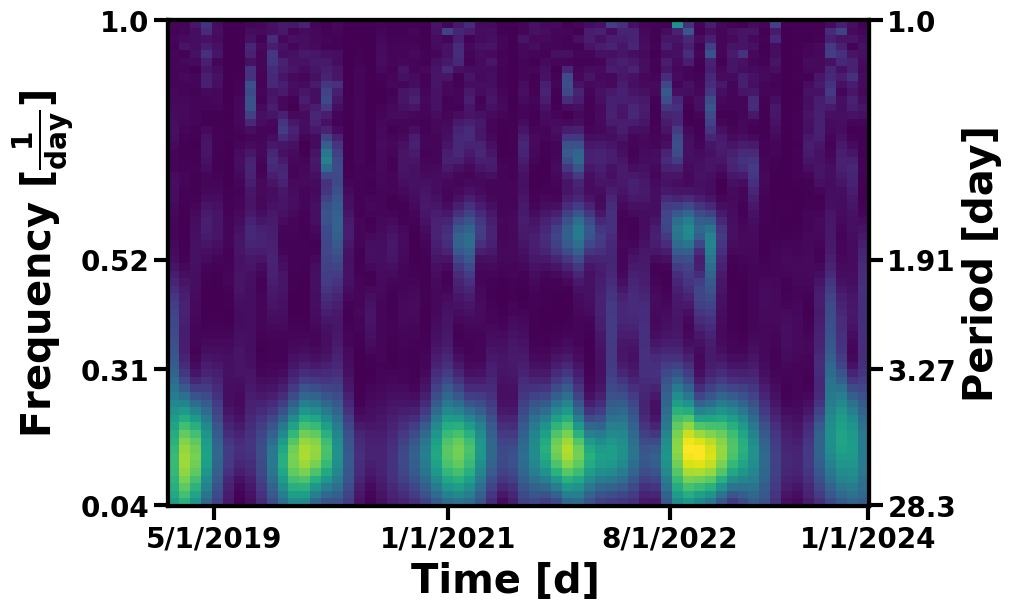

In [17]:
savedlc = pipeline(463856975202)

Pulled 1 of 1


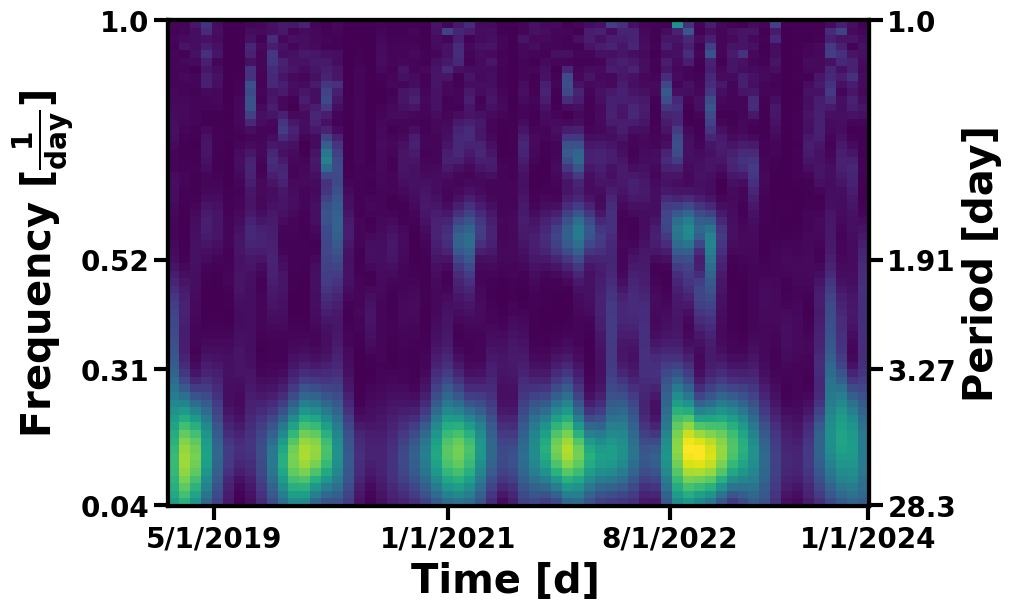

In [22]:
minmasked = pipeline(463856975202, True)

Pulled 1 of 1


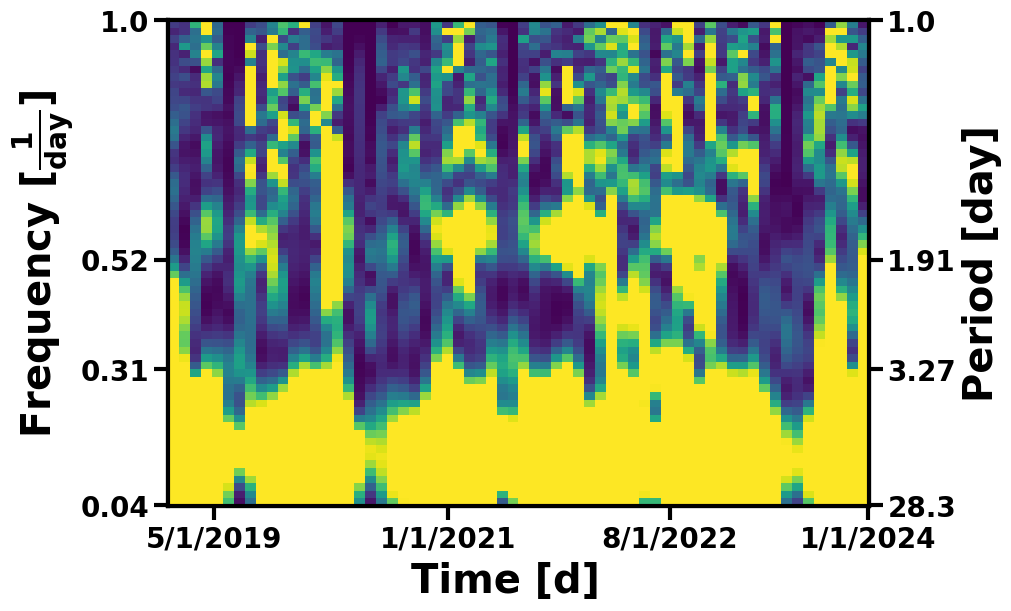

In [20]:
scaled10x = pipeline(463856975202, scaling=True)